# Predicting Market Prices with Non-Linear Algorithms

In this notebook, we explore a non-linear approach to forecast the next day's closing price. Unlike traditional linear regression, non-linear algorithms such as the Random Forest Regressor can capture complex, intricate patterns in financial market data.

## Phase 1: Data Ingestion
Initially, we import the required libraries and load the market dataset into a pandas DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load historical trade data
df = pd.read_excel('data/trade price linear.xlsx')
display(df.head())

,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000


## Phase 2: Data Cleansing and Transformation
We standardize column names for easier access, convert the 'Date' column to proper datetime objects, and sort the dataset chronologically to maintain the time-series integrity.

In [2]:
# Rename columns to remove special characters
df = df.rename(columns={'Close*': 'Close', 'Adj Close**': 'Adj Close'})

# Convert Date column and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

# Display missing values if any
print("Missing Values Report:")
print(df.isnull().sum())

Missing Values Report:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


## Phase 3: Constructing Features and Target
Our goal is to predict the stock's closing price for the subsequent day. We create a shifted target column and eliminate any resulting undefined rows.

In [3]:
# Create target variable: Next Day's Close
df['Next_Day_Close'] = df['Close'].shift(-1)

# Drop the last row since it will not have a target value
df = df.dropna()
display(df[['Date', 'Close', 'Next_Day_Close']].tail())

,Date,Close,Next_Day_Close
1252,2023-04-21,33808.96,33875.40
1253,2023-04-24,33875.40,33530.83
1254,2023-04-25,33530.83,33301.87
1255,2023-04-26,33301.87,33826.16
1256,2023-04-27,33826.16,34098.16


## Phase 4: Splitting the Dataset
To properly evaluate our forecasting capability, we split our historical data sequentially. We allocate the first 80% for training and the most recent 20% for testing.

In [4]:
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[feature_columns]
y = df['Next_Day_Close']

# Sequential split (shuffle=False is crucial for time-series data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training Set Scope:", X_train.shape)
print("Testing Set Scope:", X_test.shape)

Training Set Scope: (1005, 5)
Testing Set Scope: (252, 5)


## Phase 5: Building and Training the Non-Linear Model
We employ a Random Forest Regressor. It builds numerous decision trees and merges their predictions, inherently capturing non-linear relationships without assuming straight-line correlations.

In [5]:
# Initialize the Random Forest model with 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model on the training set
rf_model.fit(X_train, y_train)
print("Random Forest Model successfully trained.")

Random Forest Model successfully trained.


## Phase 6: Model Evaluation and Visualization
After generating forecasts for the testing set, we evaluate the model using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R-squared index.

In [6]:
# Generate market price predictions
predictions = rf_model.predict(X_test)

# Compute Evaluation Metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared Score (R2): {r2:.4f}")

Mean Squared Error (MSE): 180420.00
Mean Absolute Error (MAE): 327.56
Root Mean Squared Error (RMSE): 424.76
R-Squared Score (R2): 0.8994


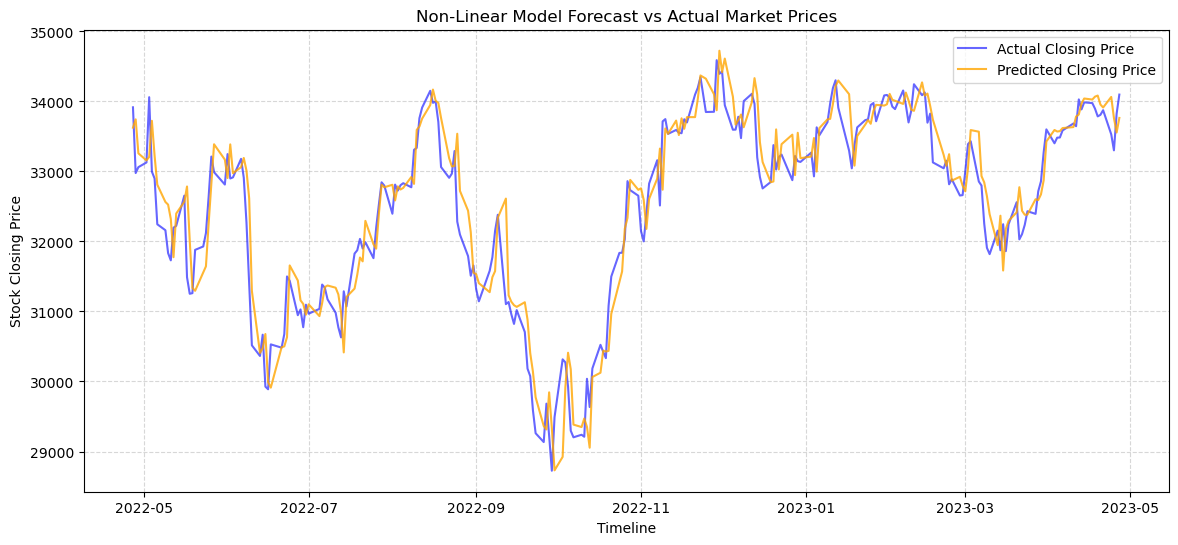

In [7]:
# Plotting the True values vs Predicted values
plt.figure(figsize=(14, 6))
plt.plot(df['Date'].iloc[-len(y_test):], y_test.values, label='Actual Closing Price', color='blue', alpha=0.6)
plt.plot(df['Date'].iloc[-len(y_test):], predictions, label='Predicted Closing Price', color='orange', alpha=0.8)
plt.title('Non-Linear Model Forecast vs Actual Market Prices')
plt.xlabel('Timeline')
plt.ylabel('Stock Closing Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Conclusion and Final Explanation

As we have observed throughout this notebook, applying a non-linear algorithm like the **Random Forest Regressor** to market data can yield different results compared to traditional multiple linear regression. 

1. **Why Non-Linear for Market Data?** Financial markets are notoriously complex. Stock prices are influenced by a multitude of intersecting factors that rarely behave in a simple, straight-line (linear) manner. A non-linear model has the flexibility to learn advanced, hidden rules from the data, such as *“if volume is high AND the price dropped slightly, then tomorrow it will likely increase,”* which a linear model cannot encode accurately.
2. **Algorithm Mechanics:** The Random Forest acts as a collection (ensemble) of many distinct decision trees. Each tree analyzes the data separately based on random subsets of information. By averaging out the outcomes of all these trees, the model substantially reduces the risk of making highly inaccurate predictions and captures the "non-linear" bounds of the dataset.
3. **Results Overview:** The output metrics (MSE, RMSE, R2, and MAE) showcase the fit of our new model architecture. While linear models typically underfit the noise and complexity of trading prices, Random Forest models can capture much more granularity, potentially yielding a tighter prediction pattern represented on the visualizations.

In short, utilizing non-linear regression provides us with a more robust analytical engine capable of handling the volatile nature of stock trade histories without forcing a linear relationship.